C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


              precision    recall  f1-score   support

     Atruman       0.55      0.75      0.63         8
     Aquacel       0.43      0.60      0.50         5
    Na_ultra       0.00      0.00      0.00         5

    accuracy                           0.50        18
   macro avg       0.32      0.45      0.38        18
weighted avg       0.36      0.50      0.42        18

Accuracy: 50.0 %


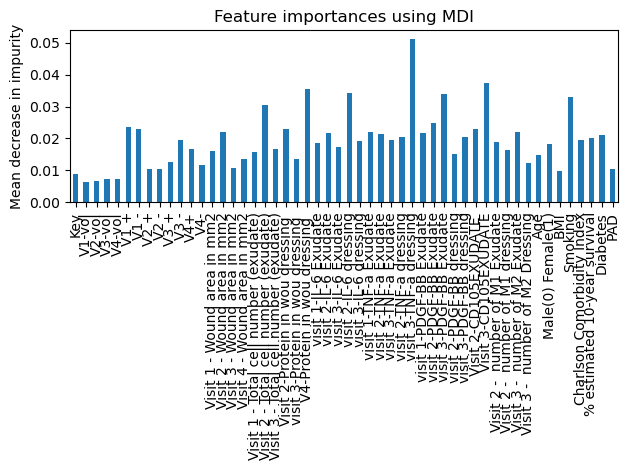

[[0.2970739  0.30493605 0.3979901 ]
 [0.41458064 0.21391878 0.37150064]
 [0.21946798 0.3882629  0.39226913]
 [0.5391811  0.20317392 0.25764492]
 [0.5069298  0.18802728 0.30504292]
 [0.50725234 0.16594706 0.32680064]
 [0.4463362  0.17305829 0.3806055 ]
 [0.4884603  0.25224572 0.25929403]
 [0.46276578 0.25197938 0.2852548 ]
 [0.34496224 0.4124192  0.24261856]
 [0.31795242 0.40651923 0.27552837]
 [0.39036027 0.38069013 0.22894955]
 [0.31341484 0.41658726 0.26999786]
 [0.36257482 0.33626446 0.3011607 ]
 [0.2864058  0.45796895 0.2556252 ]
 [0.31497377 0.4153323  0.26969397]
 [0.39847144 0.30531228 0.2962163 ]
 [0.36938247 0.3380423  0.2925753 ]]


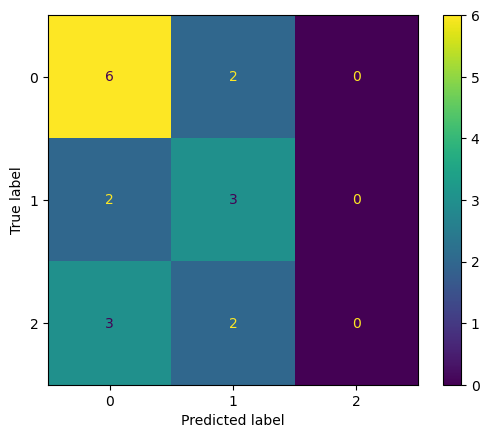

<Figure size 40000x12000 with 0 Axes>

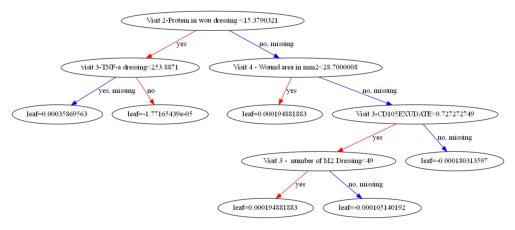

C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


              precision    recall  f1-score   support

     Atruman       1.00      1.00      1.00        20
     Aquacel       0.52      1.00      0.68        13
    Na_ultra       0.00      0.00      0.00        12

    accuracy                           0.73        45
   macro avg       0.51      0.67      0.56        45
weighted avg       0.59      0.73      0.64        45

--------------------------------------------------------------------------------------------------


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model

W_tree=1

Treatment=pd.read_csv("../AD report/pathway train.csv")
Treatment_test=pd.read_csv("../AD report/pathway test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]


#y_train = to_categorical(df_y)
#y_test = to_categorical(df_y_test)









clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="hist",
                 objective="reg:pseudohubererror",
                  eta=0.03,
                 # max_depth=4,
                  subsample=0.9,
                  #colsample_bytree=0.8,
                 # colsample_bylevel=0.9,
                 colsample_bynode=0.6,
                  reg_lambda=0.6,
                  reg_alpha=0.5,
                  rate_drop=1,
                  skip_drop=0.3,
                  one_drop=1,
                  num_parallel_tree=100,
                 # sample_type="weighted",
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test, iteration_range=(0, 50))
y_pred = (y_pred > 0.5) 


class_names=["Atruman","Aquacel","Na_ultra"]

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names
importances = clf.feature_importances_

forest_importances = pd.Series(importances, index=names)
#forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()

y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))

print("--------------------------------------------------------------------------------------------------")

target = 'key'



from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    y_train, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)
